In [1]:
library(ggplot2)
library(dplyr)
library(tidyr)
library(stringr)
library(nationalparkcolors)
library(vroom)
library(ggrepel)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘stringr’ was built under R version 4.3.2”


I pulled gene annotations for signals from the credible set, you don't have to do it that way

In [2]:
cred.set <- vroom('/nfs/lab/projects/nash_nafld_liver/GWAS/MVP_GWAS/NAFLD.EUR.MVP.2021.credset.hg38.tsv', 
                        delim='\t')
dim(cred.set)
head(cred.set)

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details, e.g.:
  dat <- vroom(...)
  problems(dat)”
Rows: 847 Columns: 19
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (8): CS.Type, LEAD.SNP, CS.SNP, EA, NEA, PP, Nominated.Gene, Biological...
dbl (10): Chr, Position, EAF, Beta, SE, P, N, chr.hg38, start.hg38, end.hg38
lgl  (1): Not.in.Trans.Ethnic

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 847  19

CS.Type,LEAD.SNP,CS.SNP,Chr,Position,EA,NEA,EAF,Beta,SE,P,N,PP,Nominated.Gene,Biological.Prior.Gene,Not.in.Trans.Ethnic,chr.hg38,start.hg38,end.hg38
<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>,<dbl>,<dbl>,<dbl>
Single SNP,rs2642438,rs2642438,1,220970028,A,G,0.295,-0.079,0.0080,0.00e+00,164197,99.54%,MTARC1,MTARC1,NA,1,220796685,220796686
NA,rs74816838,rs74816838,1,161643560,T,C,0.112,0.087,0.0128,1.09e-11,164197,96.21%,FCGR2A;FCGR2B,FCGR2A;FCGR2B,NA,1,161673769,161673770
NA,rs147998249,rs147998249,8,145732180,C,G,0.003,-2.019,0.1230,0.00e+00,164197,100.00%,GPT,GPT,NA,8,144506796,144506797
NA,rs2954038,rs2954038,8,126507389,C,A,0.306,0.139,0.0079,0.00e+00,164197,99.99%,lnc-TRIB1-2;WASHC5,TRIB1,NA,8,125495146,125495147
NA,rs10883451,rs10883451,10,101924418,C,T,0.477,-0.161,0.0073,0.00e+00,164197,98.90%,ERLIN1,ERLIN1,NA,10,100164660,100164661
NA,rs11601507,rs11601507,11,5701074,A,C,0.073,0.088,0.0139,2.16e-10,164197,99.82%,TRIM5,TRIM5,NA,11,5679843,5679844


In [3]:
cred.lead <- select(cred.set, LEAD.SNP, Biological.Prior.Gene) %>%
    distinct()

cred.lead$Gene <- str_split_fixed(cred.lead$Biological.Prior.Gene, ";", n = 2)[,1]
cred.lead <- select(cred.lead, -Biological.Prior.Gene)
dim(cred.lead)
head(cred.lead)

[1] 55  2

LEAD.SNP,Gene
<chr>,<chr>
rs2642438,MTARC1
rs74816838,FCGR2A
rs147998249,GPT
rs2954038,TRIB1
rs10883451,ERLIN1
rs11601507,TRIM5


In [4]:
str_split_fixed(cred.lead$Biological.Prior.Gene, ";", n = 2)[,1]

Warning message:
“Unknown or uninitialised column: `Biological.Prior.Gene`.”


character(0)

Consider filtering by p-value to speed up plotting (ie p < 0.01)

In [5]:
sum.stats <- vroom('/nfs/lab/projects/nash_nafld_liver/GWAS/MVP_GWAS/NAFLD.EUR.MVP.2021.hg38.tsv', 
                        delim='\t')
dim(sum.stats)
head(sum.stats)

Rows: 11657625 Columns: 13
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (3): RSID, EA, NEA
dbl (10): CHR, POS, EAF, BETA, SE, P, N, OR, chr.hg38, pos.hg38

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 11657625       13

RSID,CHR,POS,EA,NEA,EAF,BETA,SE,P,N,OR,chr.hg38,pos.hg38
<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
rs542222769,1,324826,G,A,0.0062,0.0396,0.0783,0.6128,164197,1.040,1,494511
rs559154412,1,727162,C,T,0.0020,-0.0970,0.1373,0.4799,164197,0.908,1,791782
rs182373484,1,748332,C,T,0.0054,0.0525,0.0664,0.4285,164197,1.054,1,812952
rs28544273,1,751343,A,T,0.1443,0.0006,0.0109,0.9584,164197,1.001,1,815963
rs28527770,1,751756,C,T,0.1438,0.0006,0.0109,0.9551,164197,1.001,1,816376
rs3094315,1,752566,A,G,0.8445,0.0010,0.0105,0.9236,164197,1.001,1,817186


In [6]:
sum.stats.lead <- left_join(sum.stats, cred.lead, by=join_by(RSID==LEAD.SNP))

sum(!is.na(sum.stats.lead$Gene))
dim(sum.stats.lead)
head(sum.stats.lead)

[1] 55

[1] 11657625       14

RSID,CHR,POS,EA,NEA,EAF,BETA,SE,P,N,OR,chr.hg38,pos.hg38,Gene
<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
rs542222769,1,324826,G,A,0.0062,0.0396,0.0783,0.6128,164197,1.040,1,494511,NA
rs559154412,1,727162,C,T,0.0020,-0.0970,0.1373,0.4799,164197,0.908,1,791782,NA
rs182373484,1,748332,C,T,0.0054,0.0525,0.0664,0.4285,164197,1.054,1,812952,NA
rs28544273,1,751343,A,T,0.1443,0.0006,0.0109,0.9584,164197,1.001,1,815963,NA
rs28527770,1,751756,C,T,0.1438,0.0006,0.0109,0.9551,164197,1.001,1,816376,NA
rs3094315,1,752566,A,G,0.8445,0.0010,0.0105,0.9236,164197,1.001,1,817186,NA


In [6]:
sum.stats$chr.hg38 <- factor(as.character(sum.stats$chr.hg38), levels=1:22)

Warning message:
“Removed 778438 rows containing missing values or values outside the scale range (`geom_text_repel()`).”


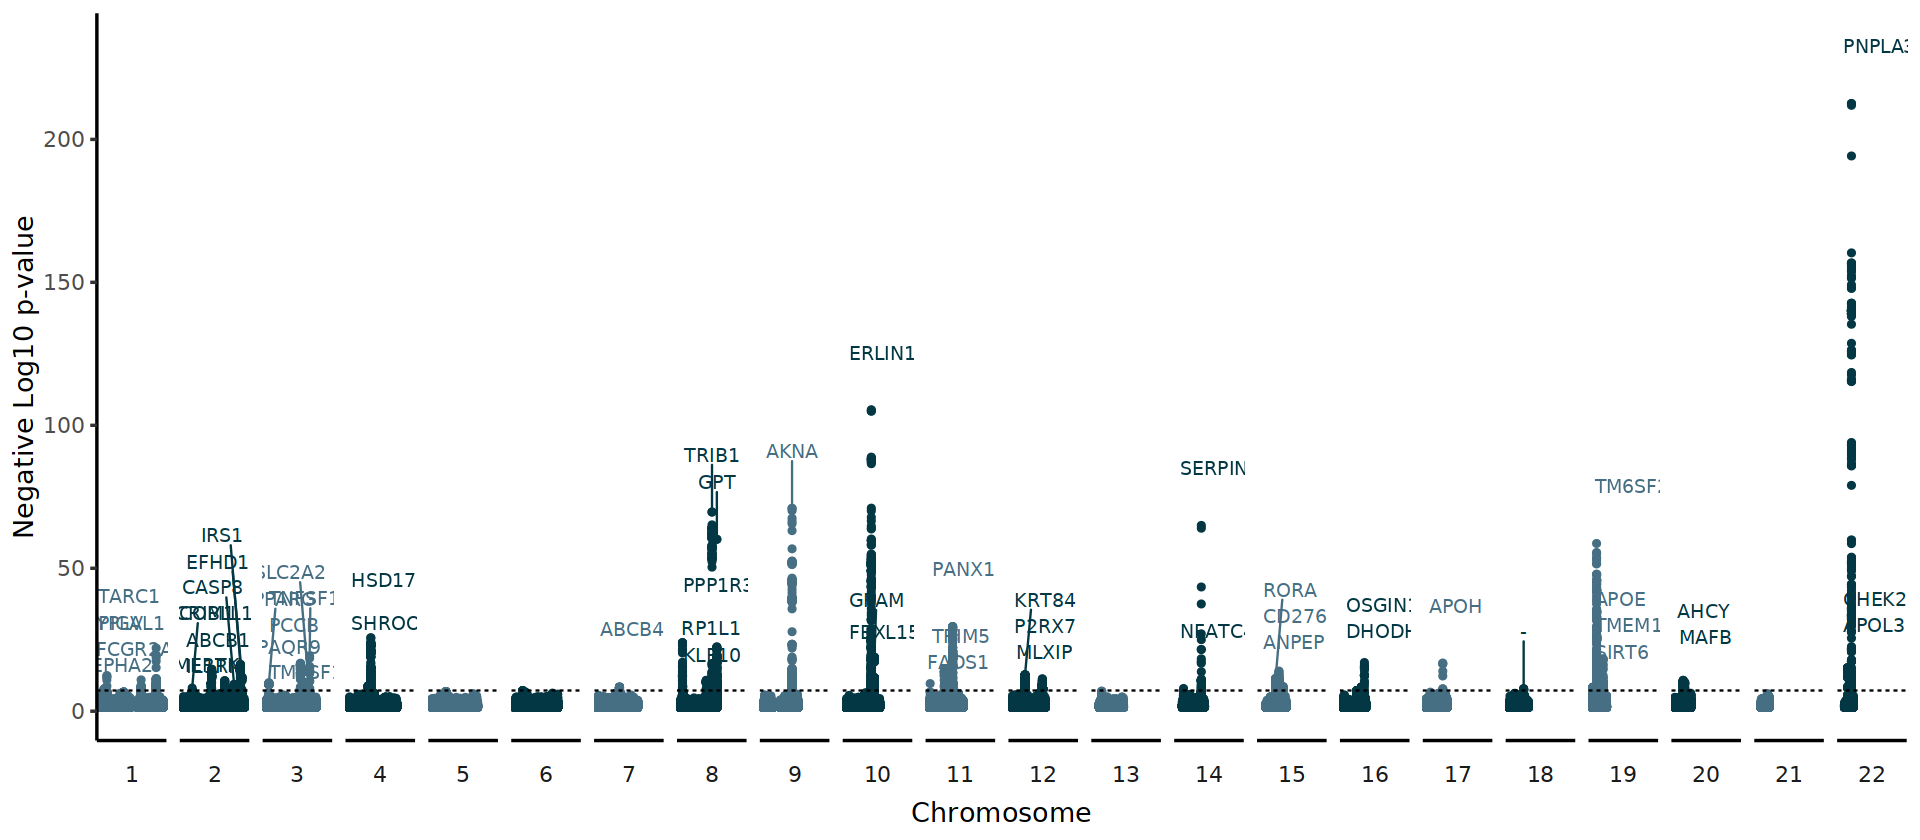

In [32]:
## My way
#options(repr.plot.width=16)
#
#ggplot(filter(sum.stats.lead,P < 0.005), aes(x=pos.hg38,y=-log10(P),color=chr.hg38, label=Gene)) + 
#    geom_point() +
#    theme_classic(base_size=16) +
#    facet_grid(~chr.hg38, switch = "x") +
#    labs(y='Negative Log10 p-value', x='Chromosome') +
#    theme(
#        strip.placement = "outside",       # Position the strip labels outside the plot area
#        strip.background = element_blank(), # Remove strip background color
#        legend.position = "none",           # Remove legend
#        axis.text.x = element_blank(),      # Remove x-axis text
#        axis.ticks.x = element_blank()      # Remove x-axis ticks
#    ) + scale_color_manual(values=rep(park_palette("Acadia")[c(4,2)], times = 11)) +
#    geom_hline(yintercept = -log10(5e-8), linetype='dashed') + 
#    geom_text_repel(nudge_y = 20)

In [33]:
head(sum.stats.lead)

RSID,CHR,POS,EA,NEA,EAF,BETA,SE,P,N,OR,chr.hg38,pos.hg38,Gene
<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<chr>
rs542222769,1,324826,G,A,0.0062,0.0396,0.0783,0.6128,164197,1.040,1,494511,NA
rs559154412,1,727162,C,T,0.0020,-0.0970,0.1373,0.4799,164197,0.908,1,791782,NA
rs182373484,1,748332,C,T,0.0054,0.0525,0.0664,0.4285,164197,1.054,1,812952,NA
rs28544273,1,751343,A,T,0.1443,0.0006,0.0109,0.9584,164197,1.001,1,815963,NA
rs28527770,1,751756,C,T,0.1438,0.0006,0.0109,0.9551,164197,1.001,1,816376,NA
rs3094315,1,752566,A,G,0.8445,0.0010,0.0105,0.9236,164197,1.001,1,817186,NA


In [39]:
don <- sum.stats.lead %>% 
  
  # Compute chromosome size
  group_by(CHR) %>% 
  summarise(chr_len=max(POS)) %>% 
  
  # Calculate cumulative position of each chromosome
  mutate(tot=cumsum(chr_len)-chr_len) %>%
  select(-chr_len) %>%
  
  # Add this info to the initial dataset
  left_join(sum.stats.lead, ., by=c("CHR"="CHR")) %>%
  
  # Add a cumulative position of each SNP
  arrange(CHR, POS) %>%
  mutate( BPcum=POS+tot)

axisdf = don %>%
  group_by(CHR) %>%
  summarize(center=( max(BPcum) + min(BPcum) ) / 2 )

Warning message:
“Removed 46555 rows containing missing values or values outside the scale range (`geom_text_repel()`).”
Warning message:
“ggrepel: 15 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


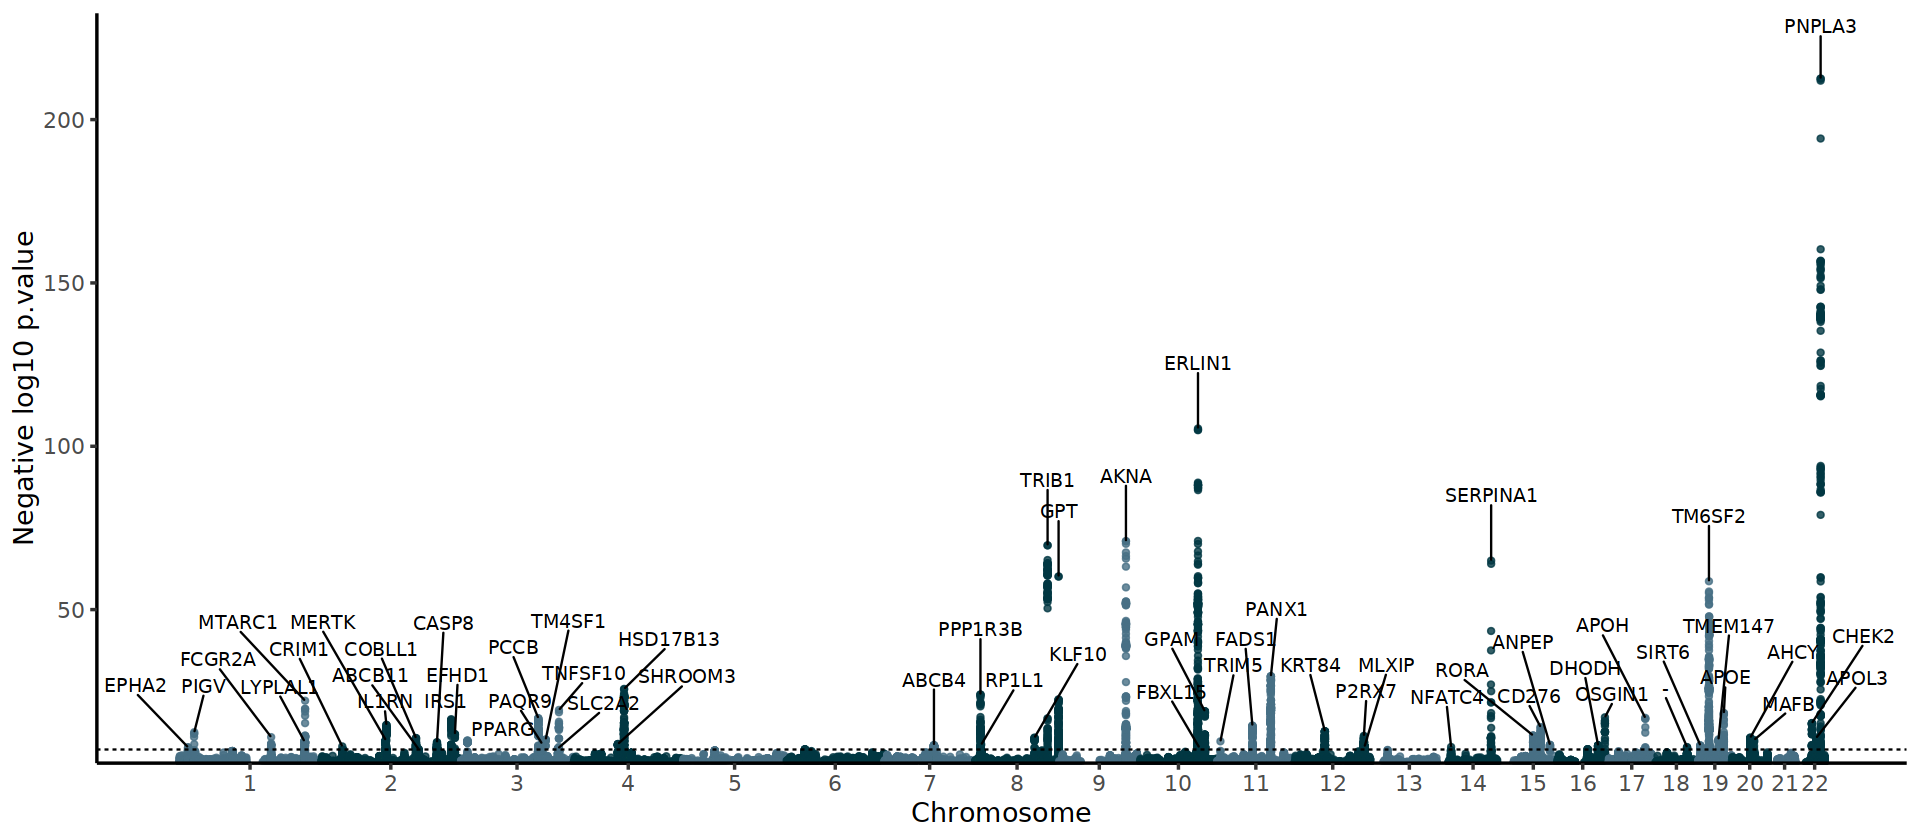

In [37]:
ggplot(filter(don, P < 0.001), aes(x=BPcum, y=-log10(P), label=Gene)) +
    
    # Show all points
    geom_point( aes(color=as.factor(CHR)), alpha=0.8, size=1.3) +
    scale_color_manual(values = rep(park_palette("Acadia")[c(4,2)], 22 )) +
    
    # custom X axis:
    scale_x_continuous( label = axisdf$CHR, breaks= axisdf$center ) +
    scale_y_continuous(expand = c(0, 0) ) +     # remove space between plot area and x axis
  
    # Custom the theme:
    theme_classic(base_size=16) +
    theme( 
      legend.position="none",
      panel.border = element_blank(),
      panel.grid.major.x = element_blank(),
      panel.grid.minor.x = element_blank()
    ) +
    
    labs(y='Negative log10 p.value', x='Chromosome') +
    geom_hline(yintercept = -log10(5e-8), linetype='dashed') + 
    geom_text_repel(nudge_y = 20)

Warning message:
“Removed 46589 rows containing missing values or values outside the scale range (`geom_text_repel()`).”


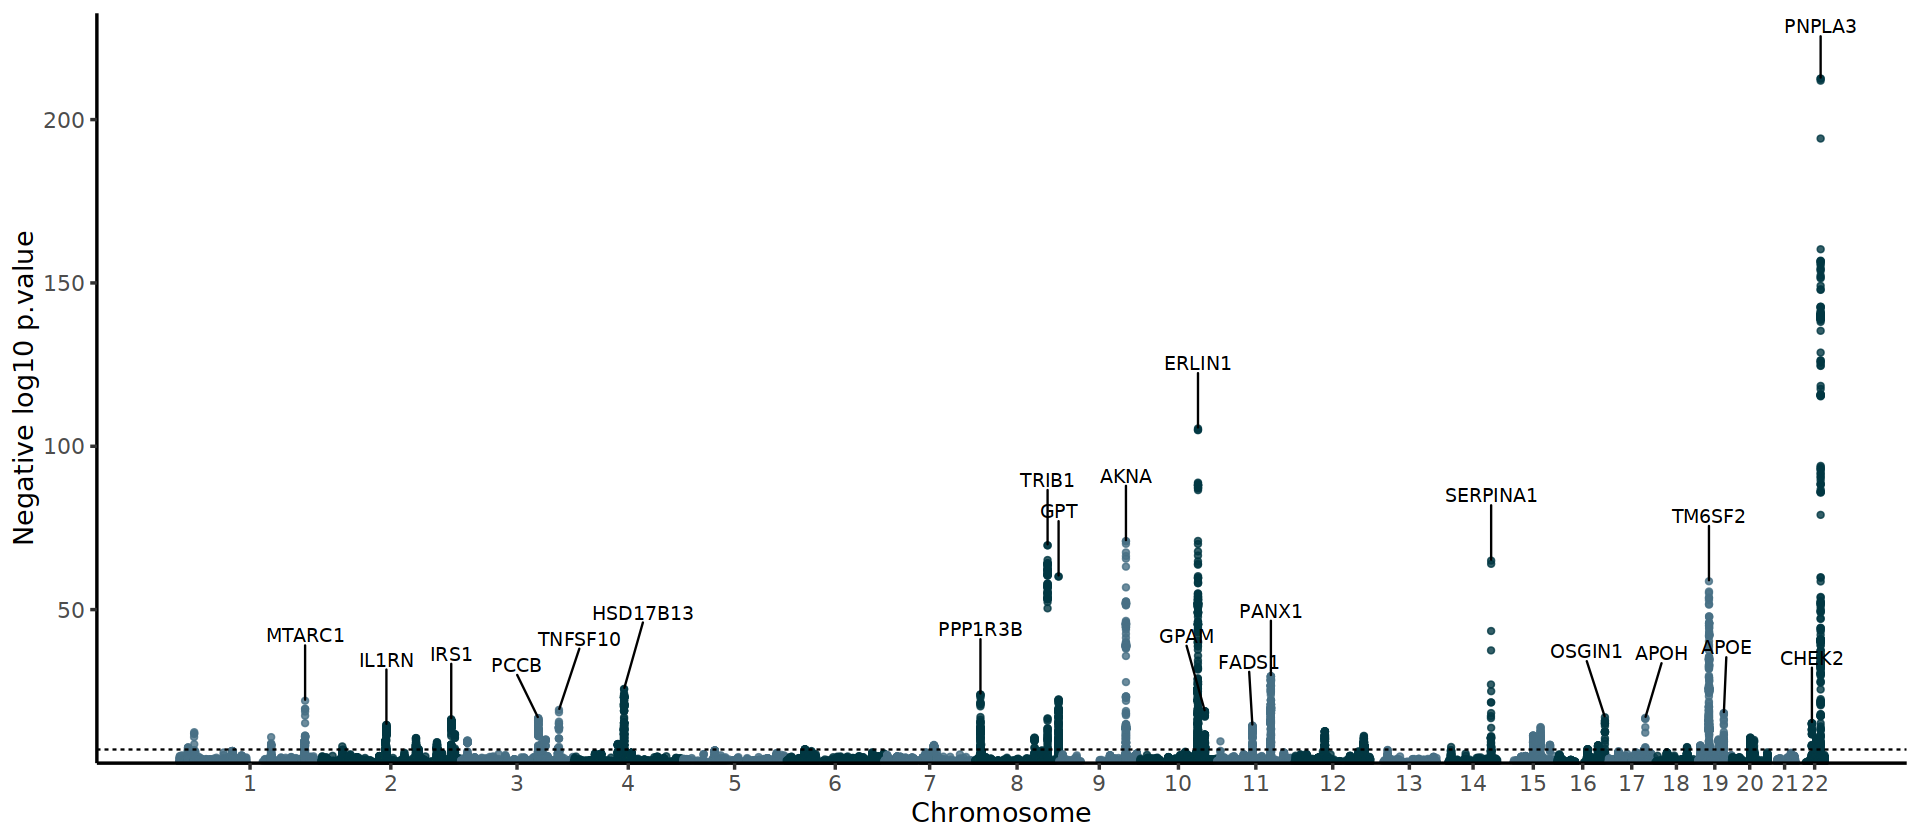

In [40]:
don[don$P > 5e-15,]$Gene <- NA

ggplot(filter(don, P < 0.001), aes(x=BPcum, y=-log10(P), label=Gene)) +
    
    # Show all points
    geom_point( aes(color=as.factor(CHR)), alpha=0.8, size=1.3) +
    scale_color_manual(values = rep(park_palette("Acadia")[c(4,2)], 22 )) +
    
    # custom X axis:
    scale_x_continuous( label = axisdf$CHR, breaks= axisdf$center ) +
    scale_y_continuous(expand = c(0, 0) ) +     # remove space between plot area and x axis
  
    # Custom the theme:
    theme_classic(base_size=16) +
    theme( 
      legend.position="none",
      panel.border = element_blank(),
      panel.grid.major.x = element_blank(),
      panel.grid.minor.x = element_blank()
    ) +
    
    labs(y='Negative log10 p.value', x='Chromosome') +
    geom_hline(yintercept = -log10(5e-8), linetype='dashed') + 
    geom_text_repel(nudge_y = 20)